In [3]:
import numpy as np
from os import listdir, makedirs
import matplotlib.pyplot as plt
from datetime import datetime
from  random import choices

import torch
import torch.onnx
from torch import nn
import torch.optim as optim

from sklearn.utils import shuffle
#from sklearn.neighbors import KernelDensity

from tqdm.notebook import tqdm

#torch.cuda.is_available()
#torch.cuda.device_count()
#torch.cuda.current_device()
#torch.cuda.get_device_name(0)
plt.style.use("seaborn-pastel")
torch.use_deterministic_algorithms(True)

C:\Users\dalbe\AppData\Local\Temp\ipykernel_44304\789981278.py:21: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-pastel")


## Setup

In [4]:
class autoencoder(nn.Module):
    def __init__(self, activation_list, layer_number = "3", layer_type = "Linear"):
        """
        # build_network

        build_network(layer_number = "3", layer_conv = None, layer_type = "Linear", activation_type = "ReLU", half=False)

        Build neural network with desired caracteristics. 

        - layer_number ("3","5","7","9" or "11") : Number of hidden layer in the bowtie network.
        - layer_conv ("None", "Conv1d") : Convolution layer in the input and output layer.
        - layer_type ("Linear") : Type of layer used.
        - activation_type ("ReLU", "Sigmoid", "CELU", "Softmax", "Softmin", "Hardshrink", "LeakyReLU", "ELU", "LogSigmoid", 
                            "PReLU", "GELU", "SiLU", "Mish", "Softplus", "Softsign", "Tanh", "GLU", "Threshold") : Type of activation function for the entire network.
        - half (True, False) : If True, only half the network is assembled, creating a triangular network with one output.
        """
        super().__init__()
        
        startEnd = 496
        if str(len(activation_list)) != layer_number:
            print("invalid activation list")

        # Layer type
        layer_type_dict = {
            "Linear" : nn.Linear
        }
        layer = layer_type_dict[layer_type]

        # Activation function
        activation_dict = {
            "ReLU"       : nn.ReLU,
            "Sigmoid"    : nn.Sigmoid,
            "CELU"       : nn.CELU, 
            "Softmax"    : nn.Softmax,
            "Softmin"    : nn.Softmin,
            "Hardshrink" : nn.Hardshrink,
            "LeakyReLU"  : nn.LeakyReLU,
            "ELU"        : nn.ELU,
            "LogSigmoid" : nn.LogSigmoid,
            "PReLU"      : nn.PReLU,
            "GELU"       : nn.GELU,
            "SiLU"       : nn.SiLU,
            "Mish"       : nn.Mish,
            "Softplus"   : nn.Softplus,
            "Softsign"   : nn.Softsign,
            "Tanh"       : nn.Tanh,
            "GLU"        : nn.GLU,
            "Threshold"  : nn.Threshold
        }

        # Number of layer
        layer_number_dict = {
            "3"  : [startEnd,248,2,248,startEnd],
            "5"  : [startEnd,330,165,1,165,330,startEnd],
            "7"  : [startEnd,372,248,124,1,124,248,372,startEnd],
            "9"  : [startEnd,400,300,200,100,1,100,200,300,400,startEnd],
            "11" : [startEnd,411,329,247,165,82,1,82,165,247,329,411,startEnd],
            "test" : [startEnd,startEnd,startEnd,startEnd,startEnd,startEnd]
        }
        layer_list = layer_number_dict[layer_number]

        # Build network
        self.encoder = nn.Sequential()
        self.decoder = nn.Sequential()

        self.encoder.append(nn.Conv1d(1, 1, kernel_size=17, stride=1, padding='same'))
        self.encoder.append(nn.Conv1d(1, 1, kernel_size=17, stride=1, padding='same'))
        
        for index, activation_type in enumerate(activation_list):
            if index < len(activation_list) // 2 + 1:
                self.encoder.append(layer(layer_list[index], layer_list[index+1]))
                self.encoder.append(activation_dict[activation_type]())
            else:
                self.decoder.append(layer(layer_list[index], layer_list[index+1]))
                self.decoder.append(activation_dict[activation_type]())
            
        self.decoder.append(layer(layer_list[-2], layer_list[-1]))

        self.decoder.append(nn.Conv1d(1, 1, kernel_size=17, stride=1, padding='same'))
        self.decoder.append(nn.Conv1d(1, 1, kernel_size=17, stride=1, padding='same'))
        
    def forward(self, x, encoding=False):
        encode = self.encoder(x)
        decode = self.decoder(encode)

        if encoding:
            return encode
        return decode
        

In [5]:
def build_dataset(batch_size ,path):
    """
    # build_dataset

    build_dataset(batch_size ,path)

    - batch_size (int) : Selects N first elements of the dataset
    - path (str) : Path to the dataset. 
    """
    TES = np.concatenate([np.fromfile(f"{path}{fileName}",dtype=np.uint16).reshape(-1,496) for fileName in listdir(path)])
    normTES = (TES - np.min(TES)) / (np.max(TES) - np.min(TES))

    # Train model to reproduce identity operation
    loader = torch.tensor(normTES[:batch_size],dtype=torch.float32).view(-1,1,496)

    return loader

In [6]:
def build_optimizer(network, learning_rate, optimizer_type="adam"):
    """
    # build_optimizer

    build_optimizer(network, learning_rate, optimizer_name="adam")

    - network (Pytorch Sequential) : Bowtie neural network that is trained to reproduce its input signal.
    - learning_rate (float) : Learning rate used in the optimizer.
    - optimizer_type ("sgd", "adam") : Type of optimizer used in the training process.
    """
    if optimizer_type == "sgd":
        optimizer = optim.SGD(network.parameters(), lr=learning_rate, momentum=0.9)
    elif optimizer_type == "adam":
        optimizer = optim.Adam(network.parameters(), lr=learning_rate)
    
    return optimizer

In [7]:
def build_criterion(criterion_type="CrossEntropy"):
    """
    # build_criterion

    build_criterion(criterion_name="CrossEntropy")

    - criterion_type ("CrossEntropy", "L1Loss") : Type ocriterion used in the training process.
    """
    criterion_dict = {
        "CrossEntropy"       : nn.CrossEntropyLoss(),
        "L1Loss"             : nn.L1Loss(),
        "MSELoss"            : nn.MSELoss(),
        "NLLLoss"            : nn.NLLLoss(),
        "HingeEmbeddingLoss" : nn.HingeEmbeddingLoss(),
        "MarginRankingLoss"  : nn.MarginRankingLoss(),
        "TripletMarginLoss"  : nn.TripletMarginLoss(),
        "KLDivLoss"          : nn.KLDivLoss()
    }
    
    return criterion_dict[criterion_type]

In [8]:
def save_object(save_object, file_name):
    """
    # save_object

    save_object(save_object, file_name)

    
    """
    try:
        np.save(f'{file_name}', arr=save_object, allow_pickle=True)
    except Exception as ex:
        print("Error during saving process : ", ex)

In [9]:
def train_epoch(network, loader, optimizer, criterion, batch_size):
    """
    # train_epoch

    train_epoch(network, loader, optimizer, criterion, batch_size)

    Training process executed for every epoch. The actions consists of setting the gradients to zero, 
    making predictions for the batch, computing the loss and its gradientand updating the weights and biases.

    - network (Pytorch Sequential) : Bowtie neural network that is trained to reproduce its input signal.
    - loader (Pytorch tensor) :  Dataset
    - optimizer (Pytorch optimizer) : Optimizer used for training.
    - criterion(Pytorch optimizer) : Criterion used for training.
    - batch_size (int) : Size of the dataset.
    """
    cumu_loss = 0
    batch_loss = np.zeros(batch_size)

    for index, data in enumerate(loader):
        optimizer.zero_grad()
        
        # Forward
        loss = criterion(network(data), data)
        cumu_loss += loss.item()

        # Backward
        loss.backward()
        optimizer.step()

        batch_loss[index] = loss.item()

    return cumu_loss / len(loader), batch_loss , network

In [10]:
def test(network, network_half, loader):
    """
    # test

    test(network, network_half, loader)

    From a trained bowtie network, a triangular network is created to associate input signals to singular values.
    This way, the triangular network acts as a dimensionality reduction technique.
    
    - network (Pytorch Sequential) : Trained bowtie neural network.
    - network_half (Pytorch Sequential) : Untrained triangular neural network.
    - loader (Pytorch tensor) :  Dataset
    """
    state_dict = network.state_dict()
    state_dict_copy = state_dict.copy()
    
    lenght = len(state_dict)/2
    for index, element in enumerate(state_dict_copy):
        if index >= lenght:
            del state_dict[f"{element}"]

    network_half.load_state_dict(state_dict)
    output = network_half(loader).detach().numpy().reshape(-1)

    return output

In [11]:
def train(config):
    """
    # train

    train(config)

    Execute a neural network experiment by creating a bowtie neural network and training it to reproduce the it's input signal.
    Once it is trained, half the network is used to associate each signal to a singular value. 
    This way, the network acts as a dimensionality reduction technique.

    - config (dict) : Dictionary with the configuration parameters
        - example : config = {
            'path_data' : 'Datasets/Guillaume Thekkadath/',
            'path_save' : 'NN Log/',
            'sweep_index' : None,
            'sweep_name' : None,
            'layer_number': '9',
            'layer_type': 'Linear',
            'layer_conv': 'None',
            'activation_list': ["ReLU","ReLU","ReLU","ReLU","ReLU"],
            'batch_size': 5000,
            'optimizer': 'adam',
            'criterion' : "L1Loss",
            'epochs': 5,
            'learning_rate': 0.001,
            }
    """
    # Initialization of loss arrays
    epoch_loss_list = np.zeros(config['epochs'])
    batch_loss_list = np.array([])

    # log path anf folder creation
    if config['sweep_name'] is not None:
        log_path = f"{config['path_save']}/{config['sweep_name']}/sweep {config['sweep_index']}"
    else:
        folder_name = datetime.now().strftime("%Y-%m-%d-%H-%M")
        log_path = f"{config['path_save']}/{folder_name}"
    makedirs(log_path)
    
    # Load dataset
    loader = build_dataset(config['batch_size'],config['path_data'])
    # Build autoencoder
    network = autoencoder(config['activation_list'], config['layer_number'], config['layer_type'])
    # Build optimizer
    optimizer = build_optimizer(network, config['learning_rate'], config['optimizer'])
    # Build criterion
    criterion = build_criterion(config['criterion'])

    # Train 
    for epoch in range(config['epochs']):
        epoch_loss, batch_loss, network = train_epoch(network, loader, optimizer, criterion, config['batch_size'])
        # Save results of epoch
        batch_loss_list = np.concatenate((batch_loss_list, batch_loss))
        epoch_loss_list[epoch] = float(epoch_loss)
    
    # Get encoder output
    results = network(loader, encoding=True).detach().numpy()

    # Save everything in Log folder
    torch.save(network.state_dict() , f"{log_path}/model.pt")
    save_object(results , f"{log_path}/results")
    save_object(epoch_loss_list , f"{log_path}/epoch_loss")
    save_object(batch_loss_list , f"{log_path}/batch_loss")
    save_object(np.array(config), f"{log_path}/log")
    
    return results

In [12]:
def sweep(name, test_number, config):
    """
    # Sweep 

    sweep(name, test_number, config)

    Train randomly created neural networks (change the activation functions). 
    The activation function are defined to keep the autoencoder structure.

    name (str) : Name of the folder created to store the runs.
    test_number (int) : Number of model to create and train.
    config (dict) : Configuration parameters to create the autoencoders.

    TODO
    - Find criteria for dimensionality reduction and add it to the sweep
    """
    activations = ["ReLU", "Sigmoid", "CELU", "Softmax", "Softmin", "Hardshrink", 
                   "LeakyReLU", "ELU", "LogSigmoid", "PReLU", "GELU", "SiLU", 
                   "Mish", "Softplus", "Softsign", "Tanh"]
    variance_log = []
    sweep_log = []
    config["sweep_name"] = name

    for index in tqdm(range(test_number), position=0):
        random_list = choices(activations, k=2)
        print(random_list)

        config["activation_list"] = random_list + list(reversed(random_list))[1:]
        config["sweep_index"] = index

        results = np.absolute(train(config))
        
        norm_results = results - np.min(results) / (np.max(results) - np.min(results))

        variance_log.append(np.var(norm_results))
        sweep_log.append(f"{[i for i in random_list]}")

    # Save sweep parameters
    log_path = f"{config['path_save']}/{config['sweep_name']}"
    save_object(sweep_log , f"{log_path}/model")
    save_object(variance_log , f"{log_path}/variance")

    return sweep_log, variance_log

## Configuration 

In [13]:
config = {
    'path_data' : 'Datasets/Guillaume Thekkadath/',
    'path_save' : 'NN Log/',
    'sweep_index' : None,
    'sweep_name' : None,
    'layer_number': '3',
    'layer_type': 'Linear',
    'layer_conv': 'None',
    'activation_list': ["GELU","ELU","GELU"],
    'batch_size': 50000,
    'optimizer': 'adam',
    'criterion' : "L1Loss",
    'epochs': 5,
    'learning_rate': 0.001,
    }

In [14]:
#results = train(config)

In [15]:
#sweep_log, variance_log = sweep("sweep-conv-2d-3", 10, config)

## Load 

In [24]:
def load_results(file_name):
    path = f"NN Log/{file_name}/"
    fig, axs = plt.subplots(1,3,figsize=(20,5))

    # Dimensionality reduction
    x = np.load(f"{path}results.npy",allow_pickle=True)
    axs[0].scatter(x[:,0,0],x[:,0,1],s=5,alpha=0.1)
    axs[0].set_ylabel("output 2")
    axs[0].set_xlabel("output 1")
    axs[0].ticklabel_format(useOffset=False)

    # Epoch Loss
    x = np.load(f"{path}epoch_loss.npy")
    axs[1].plot(x)
    axs[1].set_ylabel("loss")
    axs[1].set_xlabel("epoch")
    axs[1].ticklabel_format(useOffset=False)

    # Batch Loss
    x = np.load(f"{path}batch_loss.npy",allow_pickle=True)
    axs[2].plot(x,linewidth=0.1)
    axs[2].set_ylabel("batch loss")
    axs[2].set_xlabel("batch step")

    # Configuration
    print(np.load(f"{path}log.npy",allow_pickle=True))

{'path_data': 'Datasets/Guillaume Thekkadath/', 'path_save': 'NN Log/', 'sweep_index': 3, 'sweep_name': 'sweep-conv-2d-3', 'layer_number': '3', 'layer_type': 'Linear', 'layer_conv': 'None', 'activation_list': ['GELU', 'Tanh', 'GELU'], 'batch_size': 50000, 'optimizer': 'adam', 'criterion': 'L1Loss', 'epochs': 5, 'learning_rate': 0.001}


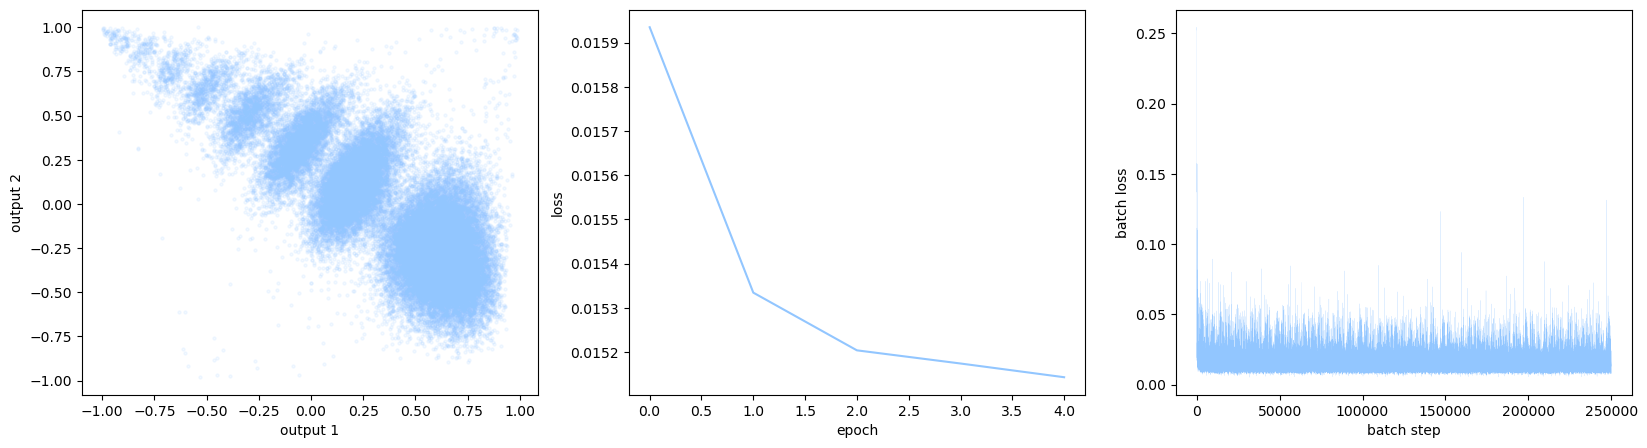

In [25]:
load_results("sweep-conv-2d-3/sweep 3")